## WHITE BLOOD CELLS CLASSIFICATION PROJECT


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os


for dirname, _, filenames in os.walk('/content/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import zipfile

# Path to the zip file
zip_file_path = '/content/white_blood_cells.zip'

# Directory to extract the contents to
extraction_path = '/content/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f'Successfully extracted {zip_file_path} to {extraction_path}')

## Use OS


In [ ]:
import os
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='1.00'

## tensorflow

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path='/content/white_blood_cells/Train'
test_path='/content/white_blood_cells/Test-A'

## Train_datagen


In [24]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

## val_test_datagen

In [25]:
val_test_datagen=ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

## val_test_datagen

In [26]:
train_data=train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

Found 8142 images belonging to 5 classes.


## val_data

In [27]:
val_data=val_test_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

Found 2033 images belonging to 5 classes.


## test_data

In [28]:
test_data=val_test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4339 images belonging to 5 classes.


## matplotlib

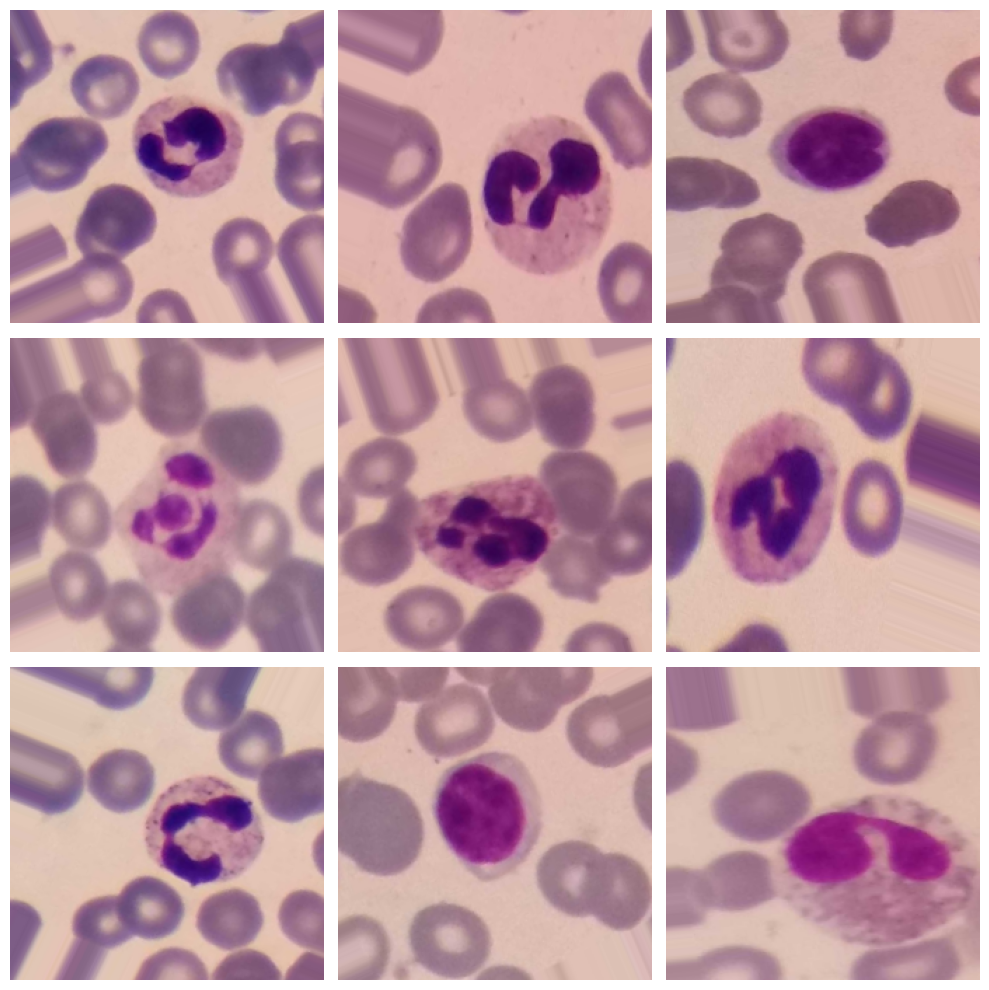

In [29]:
import matplotlib.pyplot as plt
sample_images,sample_labels=next(train_data)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(sample_images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## sklearn

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights=compute_class_weight(class_weight='balanced',classes=np.unique(train_data.classes),y=train_data.classes)
class_weights_dict=dict(enumerate(class_weights))

## class_weights_dict

In [31]:
print(class_weights_dict)

{0: np.float64(9.578823529411764), 1: np.float64(2.732214765100671), 2: np.float64(0.8385169927909372), 3: np.float64(3.626726057906459), 4: np.float64(0.32665997993981943)}


## Depthwise Convolution+Residual Connection

In [32]:
from tensorflow.keras import layers,models,Model,Input
def conv_mixer_block(x,dim,kernel_size):
    #Depthwise Convolution+Residual Connection
    residual=x
    x=layers.DepthwiseConv2D(kernel_size=kernel_size,padding='same')(x)
    x=layers.Activation('gelu')(x)
    x=layers.BatchNormalization(axis=-1)(x)
    x=layers.Add()([x,residual])
    #PointWise Convolution
    x=layers.Conv2D(filters=dim,kernel_size=1)(x)
    x=layers.Activation('gelu')(x)
    x=layers.BatchNormalization(axis=-1)(x)
    return x

## create_convmixer_model

In [33]:
def create_convmixer_model(input_shape=(224,224,3),num_classes=5,dim=256,depth=8,kernel_size=5,patch_size=4):
    inputs=layers.Input(shape=input_shape)
    x=layers.Conv2D(filters=dim,kernel_size=patch_size,strides=patch_size)(inputs)
    x=layers.Activation('gelu')(x)
    x=layers.BatchNormalization(axis=-1)(x)
    for i in range(depth):
        x=conv_mixer_block(x,dim,kernel_size)
    x=layers.GlobalAveragePooling2D()(x)
    outputs=layers.Dense(num_classes,activation='softmax')(x)
    return models.Model(inputs,outputs)

## model

In [34]:
model=create_convmixer_model()
model.summary()
Model: "functional"

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 56, 56,    │     12,544 │ input_layer[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 56, 56,    │          0 │ conv2d[0][0]      │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 56, 56,    │      1,024 │ activation[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 56, 56,    │      6,656 │ batch_normalizat… │
│ (DepthwiseConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ depthwise_conv2d… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ activation_1[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     65,792 │ add[0][0]         │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ activation_2[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │      6,656 │ batch_normalizat… │
│ (DepthwiseConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ depthwise_conv2d… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ activation_3[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     65,792 │ add_1[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 56, 56,    │          0 │ conv2d_2[0][0]  

 Total params: 610,821 (2.33 MB)

 Trainable params: 602,117 (2.30 MB)

 Non-trainable params: 8,704 (34.00 KB)

## optimizers

In [35]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC,TopKCategoricalAccuracy
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy',TopKCategoricalAccuracy(k=3,name='top3'),
                       AUC(name='auc')])

## EarlyStopping

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopper=EarlyStopping(patience=5,monitor='val_loss',restore_best_weights=True)

## history

In [ ]:
history=model.fit(train_data,validation_data=val_data,epochs=30,batch_size=32,callbacks=[early_stopper],verbose=1,class_weight=class_weights_dict)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
134/255 ━━━━━━━━━━━━━━━━━━━━ 42:53 21s/step - accuracy: 0.3742 - auc: 0.7114 - loss: 1.1513 - top3: 0.8301

## test_loss,test_accuracy,test_top3,test_auc

In [ ]:
test_loss,test_accuracy,test_top3,test_auc=model.evaluate(test_data,verbose=1)
print(f"\nTest Loss:{test_loss:.4f}")
print(f"Test Accuracy:{test_accuracy*100:.4f}%")
print(f"Test Top-3 Accuracy:{test_top3*100:.4f}%")
print(f"Test AUC:{test_auc*100:.4f}%")

## val_loss,val_accuracy,val_top3,

In [ ]:
val_loss,val_accuracy,val_top3,val_auc=model.evaluate(val_data,verbose=1)
print(f"\nValidation Loss:{val_loss:.4f}")
print(f"Validation Accuracy:{val_accuracy*100:.4f}%")
print(f"Validation Top-3 Accuracy:{val_top3*100:.4f}%")
print(f"Validation AUC:{val_auc*100:.4f}%")

## numpy

In [ ]:
import numpy as np
y_pred=model.predict(test_data)
y_pred_class=np.argmax(y_pred,axis=1)
y_true=test_data.classes

## classification_report

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report,confusion_matrix

accuracy=accuracy_score(y_true,y_pred_class)
precision=precision_score(y_true,y_pred_class,average='weighted',zero_division=1)
recall=recall_score(y_true,y_pred_class,average='weighted')
f1=f1_score(y_true,y_pred_class,average='weighted',zero_division=1)

print("\nPerformance Metrics Breakdown:")
print(f"Accuracy:{accuracy*100:.4f}%")
print(f"Precision:{precision*100:.4f}%")
print(f"Recall:{recall*100:.4f}%")
print(f"F1-Score:{f1*100:.4f}%")


In [ ]:
class_labels=list(val_data.class_indices.keys())


In [ ]:
print("Classification Report:")
print(classification_report(y_true,y_pred_class,target_names=class_labels,zero_division=1))


## save_model

In [ ]:
from tensorflow.keras.models import save_model
save_model(model,'ConvMixer_WEIGHTS_BIASES.keras')